In [2]:
import numpy as np 
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import linregress
import matplotlib.pyplot as plt
from uncertainties import ufloat
import math
from scipy.optimize import curve_fit
from scipy.optimize import fsolve

# Konstanten für Energieberechnung
hc_eV_nm = 1240  # h*c in eV*nm
h = 6.62607015e-34  # Plancksches Wirkungsquantum in Js (angepasst)
m_0 = 9.10938356e-31  # Elektronenmasse in kg (angepasst)
c= 299792458  # Lichtgeschwindigkeit in m/s (angepasst)
h_quer = h / (2 * np.pi)  # Reduziertes Plancksches Wirkungsquantum in Js (angepasst)


C:\Users\Celina\AppData\Local\Temp\ipykernel_6656\1939435997.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
df_ref= pd.read_csv(r"20-03-26\Ref.dat", skiprows=(0,1,2,3,4,5,6,7,8), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
#print(df_ref.head())

files= [r"20-03-26\2-15.dat", r"20-03-26\2-30.dat", r"20-03-26\2-45.dat", r"20-03-26\2-60.dat", r"20-03-26\2-75.dat" ]
längen= [ufloat(0.15, 0.005), ufloat(0.30, 0.005), ufloat(0.45, 0.005), ufloat(0.60, 0.005), ufloat(0.75, 0.005)] # in m , UNsicherheit von 0,005 m
unit_längen= "m"
iris3= [ufloat(10,0), ufloat(13,0), ufloat(16,0)]
unit_iris= "mm"

C:\Users\Celina\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


## Aufgabe 2: 

wenn alle peaks gefunden sind, können Kreuze entfernt werden und bild gesaved werden

Peaks in L = 0.15m:
 Anzahl der Peaks: 10
Peaks in L = 0.3m:
 Anzahl der Peaks: 20
Peaks in L = 0.45m:
 Anzahl der Peaks: 31
Peaks in L = 0.6m:
 Anzahl der Peaks: 41
Peaks in L = 0.75m:
 Anzahl der Peaks: 48


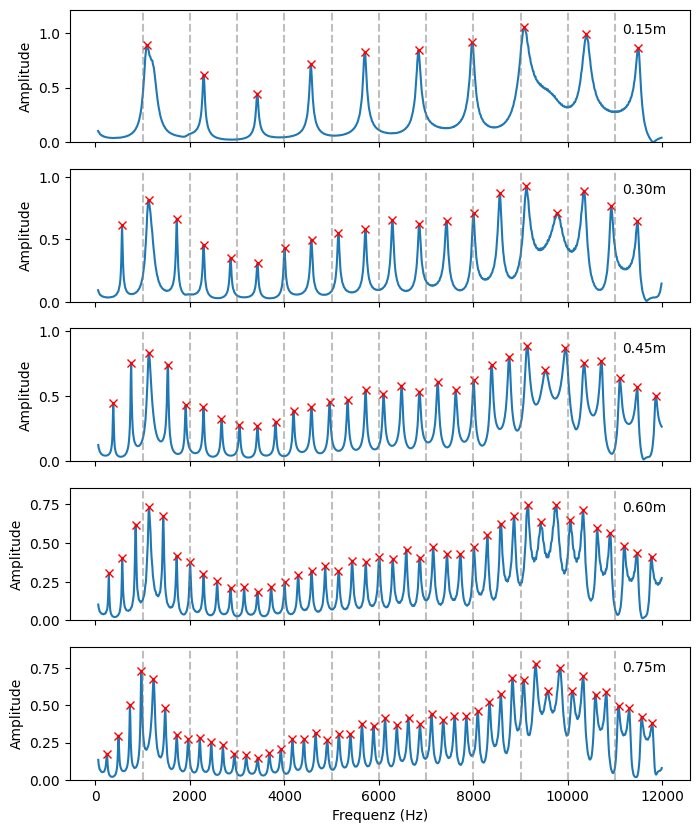

In [4]:
#Aufgabe 1 

def find_resonance_frequencies(files, label, unit_label, height= 0.05, prominence= 0.02, rel_heigth= None, width = None): # height, prominence for better peak finding, when applying on other spectrum
    fig, axes = plt.subplots(len(files), 1, sharex=True, figsize=(8,10))
    peaks_all= []
    for i, file in enumerate(files): 
        df = pd.read_csv(file, skiprows=(0,1,2,3,4,5,6,7,8), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
        #print(df.head())
        
        frequency= df["Frequenz"]
        #frequency= frequency.iloc[3:] # Entfernen der ersten zwei Zeilen, die möglicherweise Störsignale enthalten
        amplitude= df["Amplitude"] / df_ref["Amplitude"] # Normierung der Amplitude mit der Referenz
        #amplitude= amplitude.iloc[3:]
        
        axes[i].plot(frequency, amplitude)
        axes[i].text(0.89, 0.9, f"{label[i].nominal_value:.2f}{unit_label}", transform=axes[i].transAxes, verticalalignment='top')
        axes[i].set_ylabel("Amplitude")
        y_max = amplitude.max()
        axes[i].set_ylim(0, y_max * 1.15)
        
        peaks, properties = find_peaks(
            amplitude,
            height=height,        # minimale Peak-Höhe (anpassen!)
            prominence=prominence,   # wie stark der Peak herausragt
            distance=10,
            rel_height= rel_heigth,
            width=width
            )
        #  mit den Parametern werden alle Peaks gefunden! 
        #TODO hier eventuell noch mit Lorentz-Fit die Peaks genauer bestimmen
        

        axes[i].plot(frequency[peaks], amplitude[peaks], "x", color="red")  # Markieren der Peaks
        
        peaks_all.append (np.array([ufloat(frequency[peak], 5) for peak in peaks]))
        
        
    axes[-1].set_xlabel("Frequenz (Hz)")

    reference_lines = np.linspace(1000,11000, 11)

    for ax in axes:
        for line in reference_lines:
            ax.axvline(line, linestyle="--", color="gray", alpha=0.5)  
    
    return peaks_all    


peaks_all = find_resonance_frequencies(files,längen, unit_längen)
for i in np.arange(len(längen)):
    print(f"Peaks in L = {längen[i].nominal_value}m:")
    print(f" Anzahl der Peaks: {len(peaks_all[i])}")
plt.show()
#print(peaks_all[0])

c= 345+/-5
Fehler aus Fit: 5.116294007363732


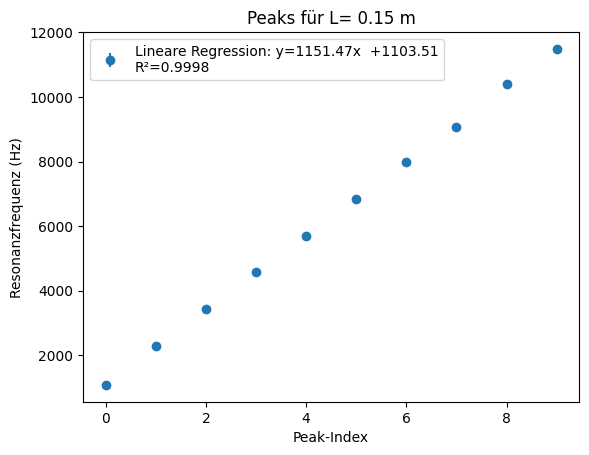

c= 344.4+/-0.8
Fehler aus Fit: 0.76219360936656


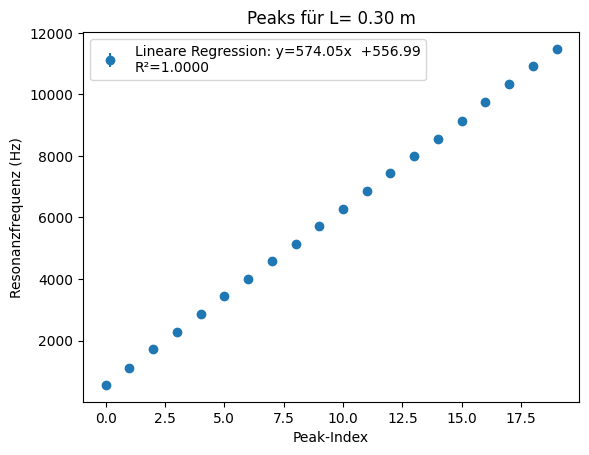

c= 344.35+/-0.29
Fehler aus Fit: 0.2949952886951002


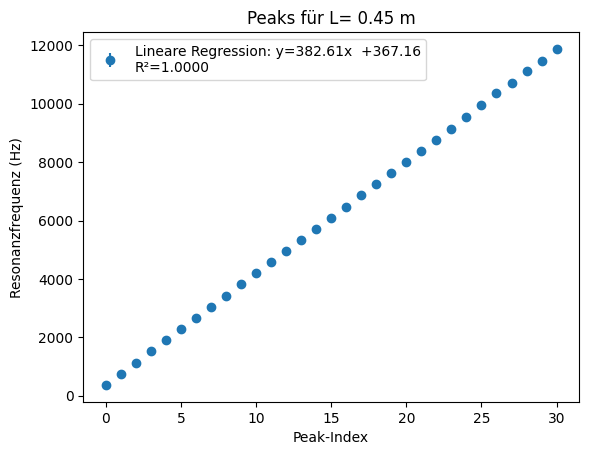

c= 344.23+/-0.16
Fehler aus Fit: 0.15771834388292877


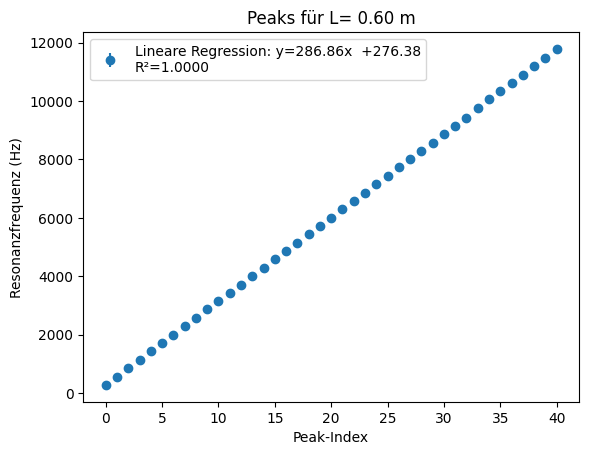

c= 368.85+/-0.11
Fehler aus Fit: 0.11418243285313769


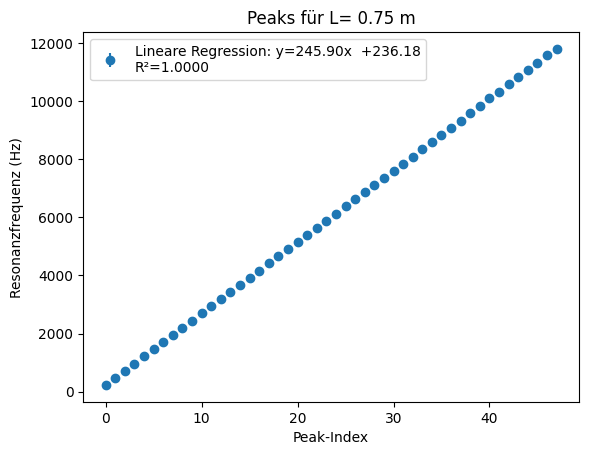

Mittlere Schallgeschwindigkeit: 349.46+/-1.04 m/s


In [5]:
c= [] # array für alle berechneten Schallgeschwindigkeiten, arrays in array für jede Länge einen

for i, peaks in enumerate(peaks_all):
    #print(peaks)
    x= np.arange(len(peaks))
    y= np.array([p.nominal_value for p in peaks])
    plt.errorbar(x, y, yerr= [p.std_dev for p in peaks], fmt='o')
    plt.xlabel("Peak-Index")
    plt.ylabel("Resonanzfrequenz (Hz)")
    plt.title(f"Peaks für L= {längen[i].nominal_value:.2f} m")
    slope, intercept, r_value, p_value, std_err = linregress(x, y) #lineare Regresssion 
    
    c.append(ufloat(slope * 2 * längen[i].nominal_value, std_err) ) #Steigung * 2 * Länge (in m) = c
    
    print(f"c= {c[-1]}")
    print(f"Fehler aus Fit: {std_err}")
    plt.legend([f"Lineare Regression: y={slope:.2f}x  {intercept:+.2f}\nR²={r_value**2:.4f}"])
    plt.show()
    
c_mean= 1/len(c) * np.sum(c)
print(f"Mittlere Schallgeschwindigkeit: {c_mean:.2f} m/s")

In [6]:
# 2 theoretische Werte

c_theo= 343  # Schallgeschwindigkeit in Luft bei 20°C in m/s
f_theo= []

for i, L in enumerate(längen):
    f= []
    print(f"theoretische Referenzfrequenzen für L= {L} m:")
    print(f"Anzahl der Peaks: {len(peaks_all[i])}")
    for n in np.arange(1, len(peaks_all[i])):  #je nach Länge, unterschiedliche Anzahl von Peaks
        f_t= n* c_theo / (2 * L) 
        f.append(f_t)
        print(f"{f_t:.2f} Hz")
    f_theo.append(f)
    
print(f_theo)

theoretische Referenzfrequenzen für L= 0.150+/-0.005 m:
Anzahl der Peaks: 10
1143.33+/-38.11 Hz
2286.67+/-76.22 Hz
3430.00+/-114.33 Hz
4573.33+/-152.44 Hz
5716.67+/-190.56 Hz
6860.00+/-228.67 Hz
8003.33+/-266.78 Hz
9146.67+/-304.89 Hz
10290.00+/-343.00 Hz
theoretische Referenzfrequenzen für L= 0.300+/-0.005 m:
Anzahl der Peaks: 20
571.67+/-9.53 Hz
1143.33+/-19.06 Hz
1715.00+/-28.58 Hz
2286.67+/-38.11 Hz
2858.33+/-47.64 Hz
3430.00+/-57.17 Hz
4001.67+/-66.69 Hz
4573.33+/-76.22 Hz
5145.00+/-85.75 Hz
5716.67+/-95.28 Hz
6288.33+/-104.81 Hz
6860.00+/-114.33 Hz
7431.67+/-123.86 Hz
8003.33+/-133.39 Hz
8575.00+/-142.92 Hz
9146.67+/-152.44 Hz
9718.33+/-161.97 Hz
10290.00+/-171.50 Hz
10861.67+/-181.03 Hz
theoretische Referenzfrequenzen für L= 0.450+/-0.005 m:
Anzahl der Peaks: 31
381.11+/-4.23 Hz
762.22+/-8.47 Hz
1143.33+/-12.70 Hz
1524.44+/-16.94 Hz
1905.56+/-21.17 Hz
2286.67+/-25.41 Hz
2667.78+/-29.64 Hz
3048.89+/-33.88 Hz
3430.00+/-38.11 Hz
3811.11+/-42.35 Hz
4192.22+/-46.58 Hz
4573.33+/-50.81

In [7]:
# 2 Abweichung der experimentellen Werte von den theoretischen ReferenzFREQUENZEN

print("Abweichung der experimentellen Werte von den theoretischen Referenzfrequenzen:")
for i in range(len(peaks_all)):
    print( f"für L= {längen[i].nominal_value:.2f} m:")
    for b,t in (zip(peaks_all[i], f_theo[i])): # array mit den Frequenzen für Länge i
        #print( b, t)
        pro_abw = abs(b - t) / t *100
        print( pro_abw)

Abweichung der experimentellen Werte von den theoretischen Referenzfrequenzen:
für L= 0.15 m:
5.2+/-3.2
0.3+/-3.4
0.2+/-3.3
0.2+/-3.3
0.2+/-3.3
0.2+/-3.3
0.4+/-3.3
0.7+/-3.3
1.0+/-3.4
für L= 0.30 m:
1.6+/-1.9
1.7+/-1.7
0.5+/-1.7
0.2+/-1.7
0.2+/-1.7
0.1+/-1.7
0.0+/-1.7
0.0+/-1.7
0.0+/-1.7
0.1+/-1.7
0.1+/-1.7
0.1+/-1.7
0.0+/-1.7
0.0+/-1.7
0.1+/-1.7
0.2+/-1.7
0.5+/-1.7
0.5+/-1.7
0.6+/-1.7
für L= 0.45 m:
1.2+/-1.7
0.8+/-1.3
1.4+/-1.2
0.2+/-1.2
0.1+/-1.1
0.0+/-1.1
0.0+/-1.1
0.0+/-1.1
0.1+/-1.1
0.2+/-1.1
0.1+/-1.1
0.1+/-1.1
0.1+/-1.1
0.0+/-1.1
0.0+/-1.1
0.0+/-1.1
0.0+/-1.1
0.0+/-1.1
0.1+/-1.1
0.1+/-1.1
0.0+/-1.1
0.1+/-1.1
0.1+/-1.1
0.1+/-1.1
0.0+/-1.1
0.4+/-1.1
0.6+/-1.1
0.4+/-1.1
0.5+/-1.1
0.3+/-1.1
für L= 0.60 m:
0.7+/-1.9
1.0+/-1.2
0.4+/-1.0
0.7+/-0.9
0.4+/-0.9
0.1+/-0.9
0.2+/-0.9
0.0+/-0.9
0.1+/-0.9
0.2+/-0.9
0.1+/-0.8
0.1+/-0.8
0.0+/-0.8
0.1+/-0.8
0.2+/-0.8
0.0+/-0.8
0.1+/-0.8
0.0+/-0.8
0.1+/-0.8
0.2+/-0.8
0.0+/-0.8
0.1+/-0.8
0.2+/-0.8
0.1+/-0.8
0.0+/-0.8
0.2+/-0.8
0.1+/-0.8
0.0+/-0.8
0

C:\Users\Celina\AppData\Local\Temp\ipykernel_6656\1118313020.py:8: FutureWarning: AffineScalarFunc.__abs__() is deprecated. It will be removed in a future release.
  pro_abw = abs(b - t) / t *100


## Aufgabe 3:

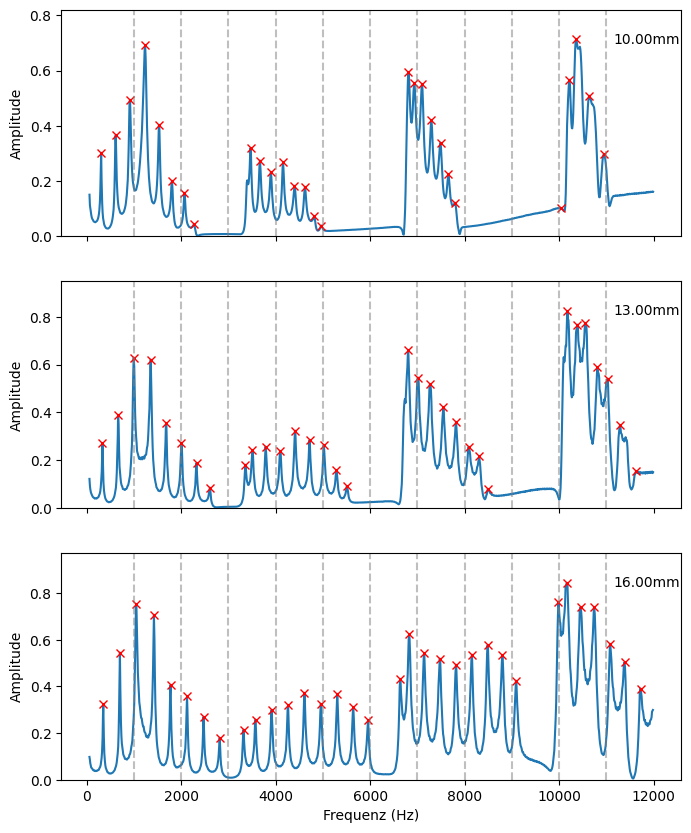

C:\Users\Celina\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


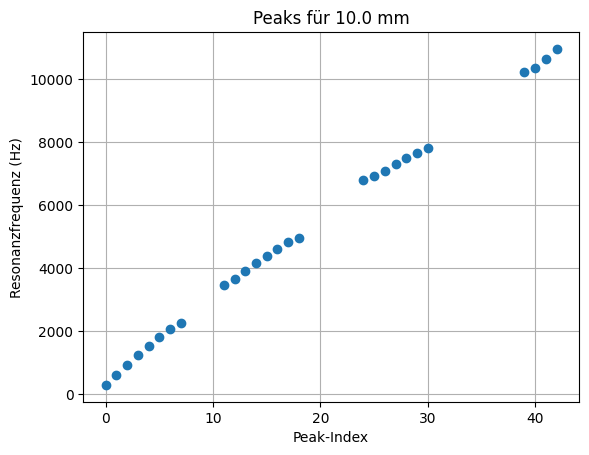

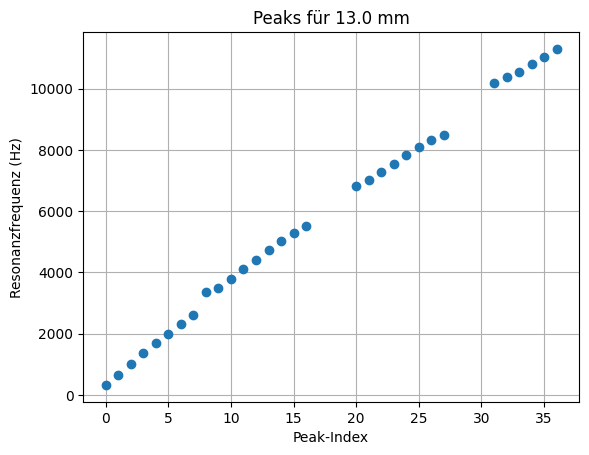

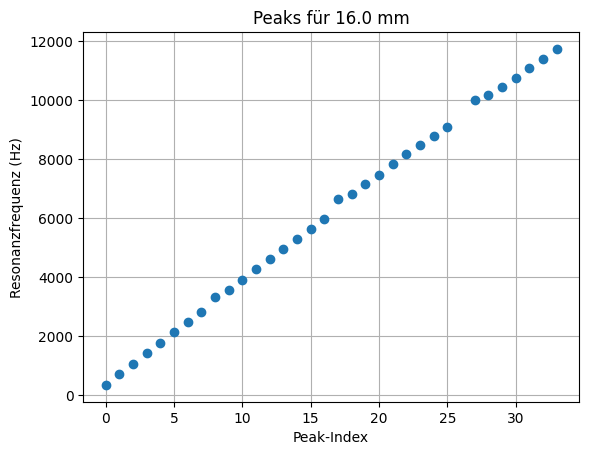

In [8]:
# 3 Bestimmung Resonanzfrequnzen für verschiedene Iris Blenden bei L= 45cm 

files3= [r"20-03-26\3-10mm.dat", r"20-03-26\3-13mm.dat", r"20-03-26\3-16mm.dat"]

peaks3_all= find_resonance_frequencies(files3, iris3, unit_iris, height=0.0005, rel_heigth= 0.2, prominence=0.009, width= (1,20))
plt.show()

peaks3_all_raw= peaks3_all.copy()
#weil nicht alle peaks erkannt werden: 
peaks3_all[1]= np.delete(peaks3_all[1],-1) # letzen bei 13mm löschen 
peaks3_all[0]= np.delete(peaks3_all[0], -5) # plateau bei kurz nach 10kHz löschen 

#print(type(peaks3_all))
#print(peaks3_all)

# leere Stellen einfügen, damit Bandlücke sichtbar wird
nan_stellen_10= [8,9,10,19,20,21,22,23,31,32,33,34,35,36,37,38]
for i in nan_stellen_10: 
    peaks3_all[0] = np.insert(peaks3_all[0],[i],[ufloat(np.nan,0)])

nan_stellen_13= [17,18,19,28,29,30]
for i in nan_stellen_13: 
    peaks3_all[1] = np.insert(peaks3_all[1],[i],[ufloat(np.nan,0)])
    
nan_stellen_16= [26]
for i in nan_stellen_16: 
    peaks3_all[2] = np.insert(peaks3_all[2],[i],[ufloat(np.nan,0)])

# Resonanzfrequnezen gegen Index
def frequency_gegen_index(peaks_all, label, unit):
    for i, peaks in enumerate(peaks_all):
        x= np.arange(len(peaks))
        y= np.array([p.nominal_value for p in peaks])
        plt.errorbar(x, y, yerr= [p.std_dev for p in peaks], fmt='o')
        plt.xlabel("Peak-Index")
        plt.ylabel("Resonanzfrequenz (Hz)")
        plt.title(f"Peaks für {label[i].nominal_value} {unit}")
        plt.grid()
        plt.show()
        #print(peaks_all[i])

frequency_gegen_index(peaks3_all, iris3, unit_iris)

### Dispersionsrelation (Aufgabe 5)

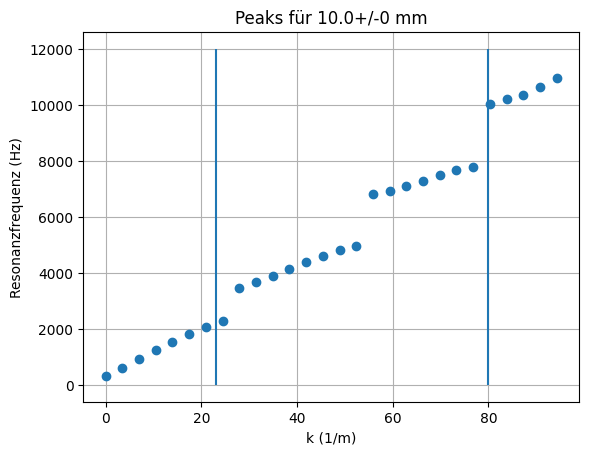

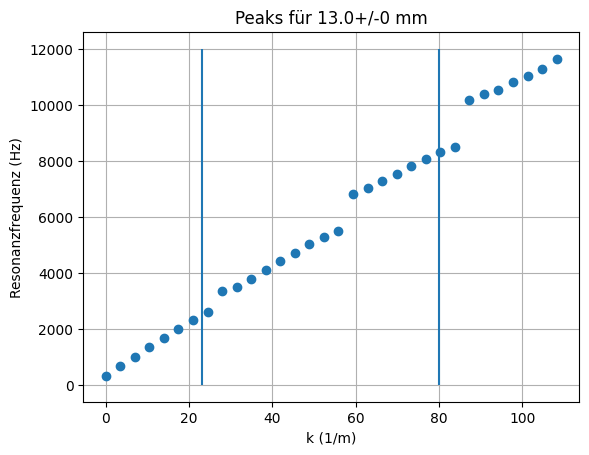

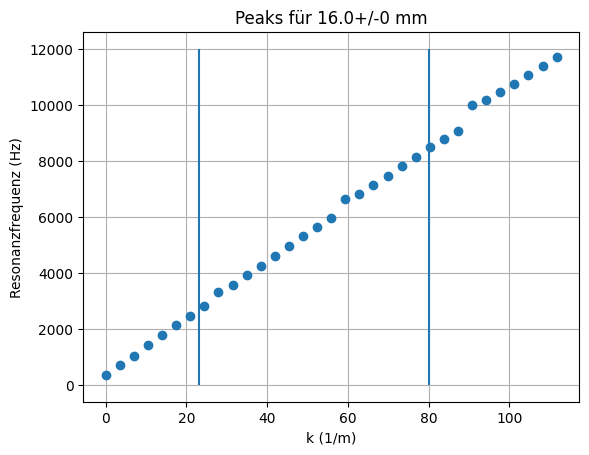

In [ ]:
# w(k) = n* c* pi / (2L)
# vlines für jede Länge anders

for i, peaks in enumerate(peaks3_all_raw):
        n= np.arange(len(peaks))
        x=n * np.pi /(2* 0.45)
        y= np.array([p.nominal_value for p in peaks])
        
        plt.vlines([23,81],0,12000 )
        plt.errorbar(x, y, yerr= [p.std_dev for p in peaks], fmt='o')
        plt.xlabel("k (1/m)")
        plt.ylabel("Resonanzfrequenz (Hz)")
        plt.title(f"Peaks für {iris3[i]} mm")
        plt.grid()
        plt.show()

### Aufgabe 4

die markierten peaks sindnicht die peaks mit denen weiter gearbeitet wird. Die werden noch angepasst.


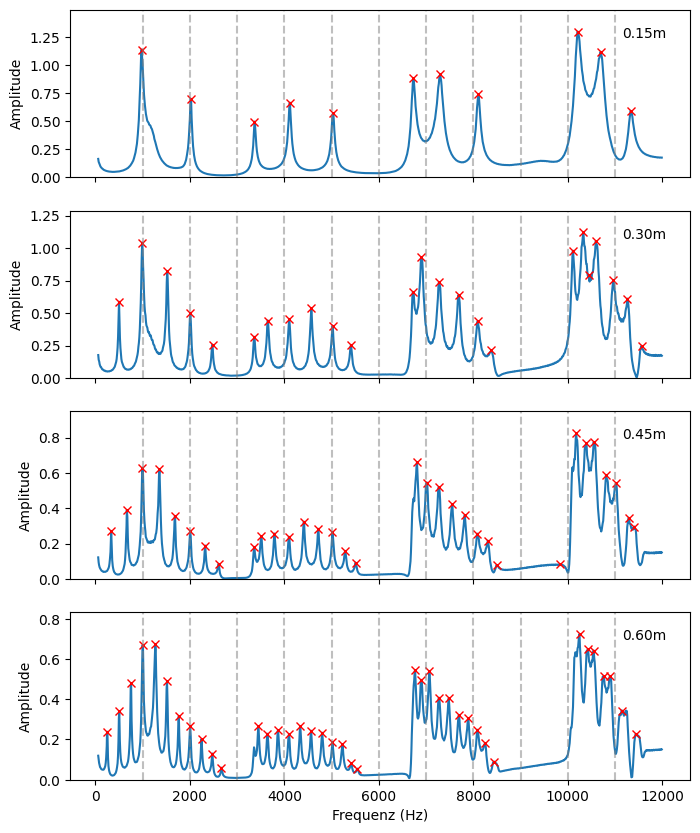

C:\Users\Celina\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


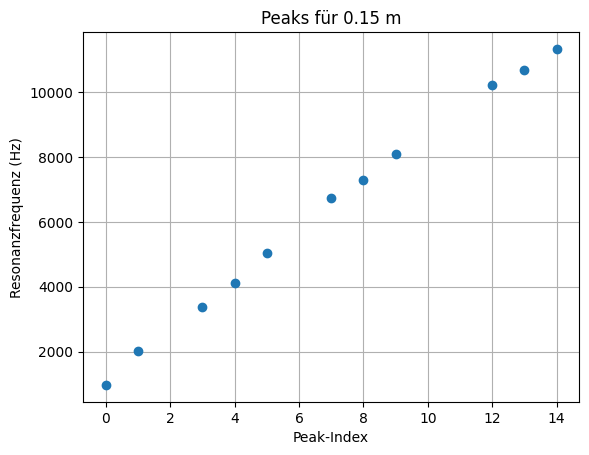

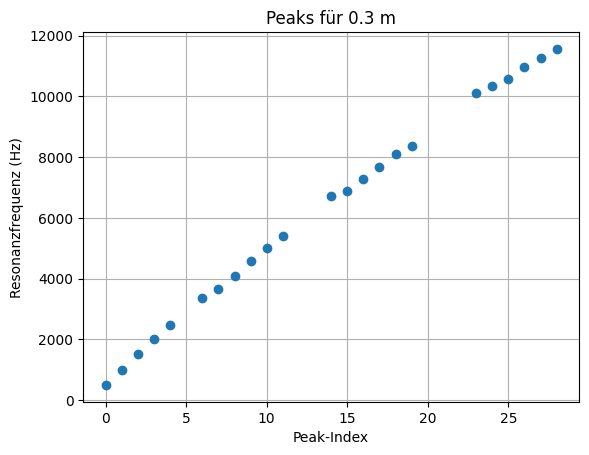

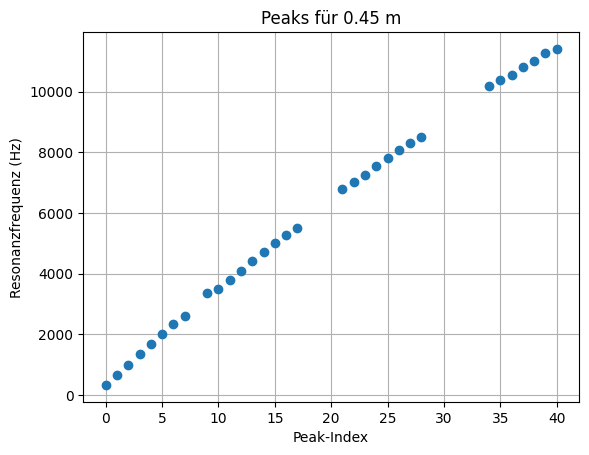

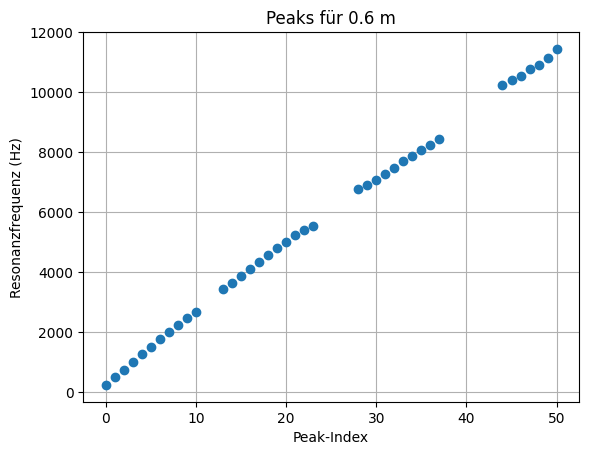

In [13]:
files4= [r"20-03-26\4-15.dat", r"20-03-26\4-30.dat", r"20-03-26\3-13mm.dat", r"20-03-26\4-60.dat"]

print("die markierten peaks sindnicht die peaks mit denen weiter gearbeitet wird. Die werden noch angepasst.") 
peaks4_all= find_resonance_frequencies(files4, längen[:-1], unit_längen, prominence= 0.01)
plt.show()

peaks4_all[1]= np.delete(peaks4_all[1],-5)
peaks4_all[2]= np.delete(peaks4_all[2],-8)

# leere Stellen einfügen, damit Bandlücke sichtbar wird
nan_stellen_15= [2,6,10,11]
for i in nan_stellen_15: 
    peaks4_all[0] = np.insert(peaks4_all[0],[i],[ufloat(np.nan,0)])

nan_stellen_30= [5,12,13,20,21,22]
for i in nan_stellen_30: 
    peaks4_all[1] = np.insert(peaks4_all[1],[i],[ufloat(np.nan,0)])
    
nan_stellen_45= [8,18,19,20,29,30,31,32,33]
for i in nan_stellen_45: 
    peaks4_all[2] = np.insert(peaks4_all[2],[i],[ufloat(np.nan,0)])
    
nan_stellen_60= [11,12,24,25,26,27,38,39,40,41,42,43]
for i in nan_stellen_60: 
    peaks4_all[3] = np.insert(peaks4_all[3],[i],[ufloat(np.nan,0)])

frequency_gegen_index(peaks4_all, längen, unit_längen)